In [30]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    classification_report,
)

# ── Consistent colour palette used across all charts ─────────
CLR_LR   = '#2196F3'   # blue  — Logistic Regression
CLR_RF   = '#4CAF50'   # green — Random Forest
CLR_GREY = '#90A4AE'   # grey  — baselines / reference lines


# ═════════════════════════════════════════════════════════════
# SECTION 1 — LOAD & PREPROCESS
# ═════════════════════════════════════════════════════════════
df = pd.read_csv(r"datasetsmall.csv")

not_dates = ['CONS_NO', 'FLAG']
date_cols = [c for c in df.columns if c not in not_dates]

# Step 1 — normalise column names to ISO dates
new_names = {c: pd.to_datetime(c, format='mixed').strftime('%Y-%m-%d') for c in date_cols}
df.rename(columns=new_names, inplace=True)
date_cols = sorted([c for c in df.columns if c not in not_dates])
df = df[not_dates + date_cols]

# Step 2 — drop all-zero rows (no useful signal)
df = df[~(df[date_cols] == 0).all(axis=1)].reset_index(drop=True)

# Step 3 — fill missing values with each row's own median
row_median = df[date_cols].median(axis=1).fillna(df[date_cols].stack().median())
for col in date_cols:
    blanks = df[col].isnull()
    df.loc[blanks, col] = row_median[blanks]

# Step 4 — log-transform to reduce skew
df_log       = df.copy()
df_log[date_cols] = np.log1p(df[date_cols])
readings     = df_log[date_cols]    # log-transformed
raw_readings = df[date_cols]        # original (for diff features)

# Step 5 — engineer features
features = pd.DataFrame()
features['CONS_NO']    = df_log['CONS_NO']
features['FLAG']       = df_log['FLAG']
features['mean_usage'] = readings.mean(axis=1)
features['std_usage']  = readings.std(axis=1)
features['min_usage']  = readings.min(axis=1)
features['max_usage']  = readings.max(axis=1)
features['iqr_usage']  = (readings.quantile(0.75, axis=1)
                          - readings.quantile(0.25, axis=1))
features['skew_usage'] = readings.skew(axis=1)
features['kurt_usage'] = readings.kurt(axis=1)
features['zero_days']  = (df[date_cols] == 0).sum(axis=1)

median_vals            = readings.median(axis=1)
features['spike_days'] = readings.gt(median_vals * 3, axis=0).sum(axis=1)

day_numbers             = np.arange(len(date_cols))
features['trend_slope'] = readings.apply(
    lambda row: np.polyfit(day_numbers, row, 1)[0],
    axis=1
)

# FIX ③ — domain-meaningful theft features + FIX ③b — fillna(False)
daily_diff = raw_readings.diff(axis=1)
prev_day   = raw_readings.shift(axis=1)

features['sudden_drop_days'] = (
    (daily_diff < -prev_day * 0.5).fillna(False)
).sum(axis=1)

features['sudden_rise_days'] = (
    (daily_diff > prev_day * 0.5).fillna(False)
).sum(axis=1)

feature_cols = [c for c in features.columns if c not in ['CONS_NO', 'FLAG']]
X = features[feature_cols]
y = features['FLAG']

# FIX ⑦ — dynamic class imbalance
theft_pct  = (y == 1).mean() * 100
normal_pct = (y == 0).mean() * 100
print(f"Class distribution  →  Normal: {normal_pct:.1f}%  |  Theft: {theft_pct:.1f}%")

# Step 6 — stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Logistic Regression — scale then SMOTE (FIX ① class_weight removed)
scaler     = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr  = scaler.transform(X_test)
X_train_lr_bal, y_train_lr_bal = SMOTE(random_state=42).fit_resample(X_train_lr, y_train)

# Random Forest — no scaling; SMOTE on raw data
X_train_rf_bal, y_train_rf_bal = SMOTE(random_state=42).fit_resample(X_train, y_train)
X_test_rf = X_test.values   # FIX ② — strip column names

print(f"\nPreprocessing complete.")
print(f"LR — Train: {X_train_lr_bal.shape}  |  Test: {X_test_lr.shape}")
print(f"RF — Train: {X_train_rf_bal.shape}  |  Test: {X_test_rf.shape}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print("=" * 60)

Class distribution  →  Normal: 91.5%  |  Theft: 8.5%

Preprocessing complete.
LR — Train: (32404, 12)  |  Test: (4429, 12)
RF — Train: (32404, 12)  |  Test: (4429, 12)
Features (12): ['mean_usage', 'std_usage', 'min_usage', 'max_usage', 'iqr_usage', 'skew_usage', 'kurt_usage', 'zero_days', 'spike_days', 'trend_slope', 'sudden_drop_days', 'sudden_rise_days']


In [17]:
# ═════════════════════════════════════════════════════════════
# SECTION 2 — MODEL DEFINITIONS
# ═════════════════════════════════════════════════════════════
lr_model = LogisticRegression(max_iter=1000, random_state=42)        
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [4]:
# ═════════════════════════════════════════════════════════════
# SECTION 3 — CROSS-VALIDATION  (FIX ④ + FIX ⑤)
# ═════════════════════════════════════════════════════════════
def _best_threshold_from_probs(y_true, y_prob):
    """Return threshold in [0.10, 0.90] that maximises F1."""
    best_f1, best_t = 0.0, 0.5
    for t in np.arange(0.10, 0.91, 0.01):
        f = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t


def run_cross_validation(X_tr, y_tr, n_splits=5):
    """
    5-fold stratified CV on X_train only .
    SMOTE inside each fold — no leakage.
    Threshold found on each validation fold, then averaged .
    """
    print(f"\n{'=' * 60}")
    print(f"  CROSS-VALIDATION ({n_splits}-Fold Stratified) — on X_train only")
    print(f"{'=' * 60}")

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    cv_pipelines = {
        'Logistic Regression': ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=42)),
            ('clf',    LogisticRegression(max_iter=1000, random_state=42)),
        ]),
        'Random Forest': ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('clf',   RandomForestClassifier(n_estimators=100,
                                             random_state=42, n_jobs=-1)),
        ]),
    }

    cv_summary   = {}
    cv_fold_f1s  = {}   # kept for box-plot visualisation

    for name, pipe in cv_pipelines.items():
        f1_scores, auc_scores, thresholds = [], [], []

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr, y_tr), 1):
            Xf_tr  = X_tr.iloc[tr_idx];  yf_tr  = y_tr.iloc[tr_idx]
            Xf_val = X_tr.iloc[val_idx]; yf_val = y_tr.iloc[val_idx]

            pipe.fit(Xf_tr, yf_tr)
            y_prob_val  = pipe.predict_proba(Xf_val)[:, 1]

            fold_thresh = _best_threshold_from_probs(yf_val, y_prob_val)  # FIX ⑤
            y_pred_val  = (y_prob_val >= fold_thresh).astype(int)

            fold_f1  = f1_score(yf_val, y_pred_val, zero_division=0)
            fold_auc = roc_auc_score(yf_val, y_prob_val)

            #  — explicit zero-division warning
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always")
                _ = precision_score(yf_val, y_pred_val, zero_division=0)
                if caught:
                    print(f"  ⚠  Fold {fold} [{name}]: zero-division in precision "
                          f"(thresh={fold_thresh:.2f})")

            f1_scores.append(fold_f1)
            auc_scores.append(fold_auc)
            thresholds.append(fold_thresh)

        f1_mean   = np.mean(f1_scores);  f1_std   = np.std(f1_scores)
        auc_mean  = np.mean(auc_scores); auc_std  = np.std(auc_scores)
        avg_thresh = round(float(np.mean(thresholds)), 2)
        
        print(f"\n  {name}")
        print(f"    F1  per fold  : {[round(v,4) for v in f1_scores]}")
        print(f"    F1  mean±std  : {f1_mean:.4f} ± {f1_std:.4f}")
        print(f"    AUC per fold  : {[round(v,4) for v in auc_scores]}")
        print(f"    AUC mean±std  : {auc_mean:.4f} ± {auc_std:.4f}")
        print(f"    Thresholds    : {[round(t,2) for t in thresholds]}")
        print(f"    Avg threshold : {avg_thresh:.2f}  ← applied to test set")

        if f1_std > 0.10:
            print(f"    ⚠  High F1 variance (std={f1_std:.4f}) — model may be unstable.")

        cv_summary[name]  = {
            'F1 Mean': round(f1_mean, 4), 'F1 Std': round(f1_std, 4),
            'AUC Mean': round(auc_mean, 4), 'AUC Std': round(auc_std, 4),
            'Avg Threshold': avg_thresh,
        }
        cv_fold_f1s[name] = f1_scores

    return cv_summary, cv_fold_f1s


cv_results, cv_fold_f1s = run_cross_validation(X_train, y_train, n_splits=5)


  CROSS-VALIDATION (5-Fold Stratified) — on X_train only

  Logistic Regression
    F1  per fold  : [0.2321, 0.2512, 0.2326, 0.2487, 0.2326]
    F1  mean±std  : 0.2394 ± 0.0086
    AUC per fold  : [np.float64(0.6503), np.float64(0.6685), np.float64(0.6583), np.float64(0.6683), np.float64(0.6452)]
    AUC mean±std  : 0.6581 ± 0.0094
    Thresholds    : [np.float64(0.66), np.float64(0.64), np.float64(0.6), np.float64(0.59), np.float64(0.59)]
    Avg threshold : 0.62  ← applied to test set

  Random Forest
    F1  per fold  : [0.235, 0.2059, 0.2227, 0.2072, 0.208]
    F1  mean±std  : 0.2157 ± 0.0114
    AUC per fold  : [np.float64(0.6455), np.float64(0.6279), np.float64(0.641), np.float64(0.6167), np.float64(0.6079)]
    AUC mean±std  : 0.6278 ± 0.0142
    Thresholds    : [np.float64(0.48), np.float64(0.41), np.float64(0.33), np.float64(0.31), np.float64(0.45)]
    Avg threshold : 0.40  ← applied to test set


In [20]:
# ═════════════════════════════════════════════════════════════
# SECTION 4 — TRAIN FINAL MODELS
# ═════════════════════════════════════════════════════════════
lr_model.fit(X_train_lr_bal, y_train_lr_bal)
rf_model.fit(X_train_rf_bal, y_train_rf_bal)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [28]:
# ═════════════════════════════════════════════════════════════
# SECTION 5 — EVALUATE ON TEST SET
# ═════════════════════════════════════════════════════════════
def _safe_metrics(y_te, y_pred, y_prob, model_name):
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred,    zero_division=0)
    f1   = f1_score(y_te, y_pred,        zero_division=0)
    if y_pred.sum() == 0:                                      
        print(f"\n  ⚠  [{model_name}] Predicted NO positives — "
              f"Precision/Recall/F1 = 0.")
    return (prec, rec, f1,
            accuracy_score(y_te, y_pred),
            mean_absolute_error(y_te, y_pred),
            np.sqrt(mean_squared_error(y_te, y_pred)),
            r2_score(y_te, y_pred),
            roc_auc_score(y_te, y_prob))


def evaluate_model(model, model_name, X_te, y_te, threshold):
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int) 

    prec, rec, f1, acc, mae, rmse, r2, auc_val = _safe_metrics(
        y_te, y_pred, y_prob, model_name)
    error_rate = 1 - acc
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()

    print(f"\n{'=' * 60}")
    print(f"  MODEL : {model_name}  (CV-averaged threshold = {threshold:.2f})")
    print(f"{'=' * 60}")
    print(f"\n  Confusion Matrix:")
    print(f"  ┌───────────────────────────────────────────────┐")
    print(f"  │                  Predicted                    │")
    print(f"  │             Normal     │     Theft            │")
    print(f"  │  Normal   TN = {tn:<6}  │  FP = {fp:<6}       │")
    print(f"  │  Theft    FN = {fn:<6}  │  TP = {tp:<6}       │")
    print(f"  └───────────────────────────────────────────────┘")
    print(f"  Thieves correctly caught (TP) : {tp}")
    print(f"  Thieves missed           (FN) : {fn}")
    print(f"  False alarms             (FP) : {fp}")
    print(f"  Normal correctly cleared (TN) : {tn}")
    print(f"\n  Metrics:")
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  Error Rate : {error_rate:.4f}")
    print(f"  Precision  : {prec:.4f}")
    print(f"  Recall     : {rec:.4f}")
    print(f"  F1-Score   : {f1:.4f}")
    print(f"  MAE        : {mae:.4f}")
    print(f"  RMSE       : {rmse:.4f}")
    print(f"  R²         : {r2:.4f}")
    print(f"  AUC        : {auc_val:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred,
                                target_names=['Normal', 'Theft'],
                                zero_division=0))

    return {
        'Model': model_name, 'Threshold': threshold,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Accuracy':   round(acc,        4),
        'Error Rate': round(error_rate, 4),
        'Precision':  round(prec,       4),
        'Recall':     round(rec,        4),
        'F1-Score':   round(f1,         4),
        'MAE':        round(mae,        4),
        'RMSE':       round(rmse,       4),
        'R2':         round(r2,         4),
        'AUC':        round(auc_val,    4),
        'y_prob':     y_prob,
        'y_pred':     y_pred,
    }


lr_thresh  = cv_results['Logistic Regression']['Avg Threshold']
rf_thresh  = cv_results['Random Forest']['Avg Threshold']

lr_results = evaluate_model(lr_model, 'Logistic Regression', X_test_lr, y_test, lr_thresh)
rf_results = evaluate_model(rf_model, 'Random Forest',       X_test_rf, y_test, rf_thresh)


  MODEL : Logistic Regression  (CV-averaged threshold = 0.62)

  Confusion Matrix:
  ┌───────────────────────────────────────────────┐
  │                  Predicted                    │
  │             Normal     │     Theft            │
  │  Normal   TN = 3584    │  FP = 467          │
  │  Theft    FN = 264     │  TP = 114          │
  └───────────────────────────────────────────────┘
  Thieves correctly caught (TP) : 114
  Thieves missed           (FN) : 264
  False alarms             (FP) : 467
  Normal correctly cleared (TN) : 3584

  Metrics:
  Accuracy   : 0.8350
  Error Rate : 0.1650
  Precision  : 0.1962
  Recall     : 0.3016
  F1-Score   : 0.2377
  MAE        : 0.1650
  RMSE       : 0.4063
  R²         : -1.1143
  AUC        : 0.6558

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.88      0.91      4051
       Theft       0.20      0.30      0.24       378

    accuracy                           0.83      4429


C:\Users\eman8\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [22]:
# ═════════════════════════════════════════════════════════════
# SECTION 6 — COMPARISON TABLE  (text)
# ═════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  COMPARISON — Logistic Regression vs Random Forest")
print("=" * 60)

metrics_list = ['Accuracy', 'Error Rate', 'Precision',
                'Recall', 'F1-Score', 'MAE', 'RMSE', 'R2', 'AUC']
lower_better = {'Error Rate', 'MAE', 'RMSE'}

print(f"\n  {'Metric':<14} {'Logistic Reg':>14} {'Random Forest':>14}  {'Winner':>10}")
print(f"  {'─' * 58}")
for m in metrics_list:
    lv, rv = lr_results[m], rf_results[m]
    if m in lower_better:
        winner = 'LR ✓' if lv < rv else ('RF ✓' if rv < lv else 'Tie')
    else:
        winner = 'LR ✓' if lv > rv else ('RF ✓' if rv > lv else 'Tie')
    print(f"  {m:<14} {lv:>14.4f} {rv:>14.4f}  {winner:>10}")

print(f"\n  {'Metric':<14} {'Logistic Reg':>14} {'Random Forest':>14}")
print(f"  {'─' * 44}")
for k in ['TP', 'FP', 'FN', 'TN']:
    print(f"  {k:<14} {lr_results[k]:>14} {rf_results[k]:>14}")

print(f"\n  {'Threshold':<14} {lr_results['Threshold']:>14.2f} {rf_results['Threshold']:>14.2f}")
print(f"  (thresholds derived from CV folds — no test-set leakage)")

print(f"\n{'=' * 60}")
print(f"  CROSS-VALIDATION SUMMARY (5-Fold, on X_train only)")
print(f"{'=' * 60}")
print(f"\n  {'Model':<22} {'F1 Mean':>10} {'F1 Std':>10} "
      f"{'AUC Mean':>10} {'AUC Std':>10} {'Thresh':>8}")
print(f"  {'─' * 70}")
for name, s in cv_results.items():
    print(f"  {name:<22} {s['F1 Mean']:>10.4f} {s['F1 Std']:>10.4f} "
          f"{s['AUC Mean']:>10.4f} {s['AUC Std']:>10.4f} {s['Avg Threshold']:>8.2f}")



  COMPARISON — Logistic Regression vs Random Forest

  Metric           Logistic Reg  Random Forest      Winner
  ──────────────────────────────────────────────────────────
  Accuracy               0.8350         0.7595        LR ✓
  Error Rate             0.1650         0.2405        LR ✓
  Precision              0.1962         0.1506        LR ✓
  Recall                 0.3016         0.3915        RF ✓
  F1-Score               0.2377         0.2175        LR ✓
  MAE                    0.1650         0.2405        LR ✓
  RMSE                   0.4063         0.4904        LR ✓
  R2                    -1.1143        -2.0804        LR ✓
  AUC                    0.6558         0.6409        LR ✓

  Metric           Logistic Reg  Random Forest
  ────────────────────────────────────────────
  TP                        114            148
  FP                        467            835
  FN                        264            230
  TN                       3584           3216

  Threshold

In [29]:
# ═════════════════════════════════════════════════════════════
# SECTION 7 — ANALYSIS & DISCUSSION  (text)
# ═════════════════════════════════════════════════════════════
better = ('Random Forest'
          if rf_results['F1-Score'] > lr_results['F1-Score'] or (
              rf_results['F1-Score'] == lr_results['F1-Score'] and
              rf_results['AUC'] >= lr_results['AUC'])
          else 'Logistic Regression')

print(f"""
{'=' * 60}
  ANALYSIS & DISCUSSION
{'=' * 60}

  Overall Winner: {better}

  Dataset class balance (computed from data):
    Normal consumers : {normal_pct:.1f}%
    Theft consumers  : {theft_pct:.1f}%
    → A dummy model always predicting Normal would score {normal_pct:.1f}%
      accuracy but catch ZERO thieves. Use F1 and AUC.

  Recall  (catching thieves):
    LR : {lr_results['Recall']*100:.1f}%  → TP={lr_results['TP']}  FN={lr_results['FN']} missed
    RF : {rf_results['Recall']*100:.1f}%  → TP={rf_results['TP']}  FN={rf_results['FN']} missed

  Precision  (avoiding false alarms):
    LR : {lr_results['Precision']*100:.1f}%  → FP={lr_results['FP']} false alarms
    RF : {rf_results['Precision']*100:.1f}%  → FP={rf_results['FP']} false alarms

  F1-Score  :  LR={lr_results['F1-Score']:.4f}   RF={rf_results['F1-Score']:.4f}
  AUC       :  LR={lr_results['AUC']:.4f}   RF={rf_results['AUC']:.4f}

  CV Stability:
    LR  F1 = {cv_results['Logistic Regression']['F1 Mean']:.4f} ± {cv_results['Logistic Regression']['F1 Std']:.4f}
    RF  F1 = {cv_results['Random Forest']['F1 Mean']:.4f} ± {cv_results['Random Forest']['F1 Std']:.4f}

  Winner: {better}
    Electricity theft detection must catch real thieves (Recall)
    while keeping false alarms reasonable (Precision).
    F1-Score balances both — {better} wins on this metric.
""")




  ANALYSIS & DISCUSSION

  Overall Winner: Logistic Regression

  Dataset class balance (computed from data):
    Normal consumers : 91.5%
    Theft consumers  : 8.5%
    → A dummy model always predicting Normal would score 91.5%
      accuracy but catch ZERO thieves. Use F1 and AUC.

  Recall  (catching thieves):
    LR : 30.2%  → TP=114  FN=264 missed
    RF : 39.1%  → TP=148  FN=230 missed

  Precision  (avoiding false alarms):
    LR : 19.6%  → FP=467 false alarms
    RF : 15.1%  → FP=835 false alarms

  F1-Score  :  LR=0.2377   RF=0.2175
  AUC       :  LR=0.6558   RF=0.6409

  CV Stability:
    LR  F1 = 0.2394 ± 0.0086
    RF  F1 = 0.2157 ± 0.0114

  Winner: Logistic Regression
    Electricity theft detection must catch real thieves (Recall)
    while keeping false alarms reasonable (Precision).
    F1-Score balances both — Logistic Regression wins on this metric.



In [24]:
# ═════════════════════════════════════════════════════════════
# SECTION 8 — VISUALIZATIONS
# ═════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  GENERATING VISUALIZATIONS ...")
print("=" * 60)

# ── shared style ─────────────────────────────────────────────
plt.rcParams.update({
    'font.family'  : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'    : True,
    'grid.alpha'   : 0.25,
    'grid.linestyle': '--',
})

LABELS   = ['Logistic Regression', 'Random Forest']
COLORS   = [CLR_LR, CLR_RF]



  GENERATING VISUALIZATIONS ...


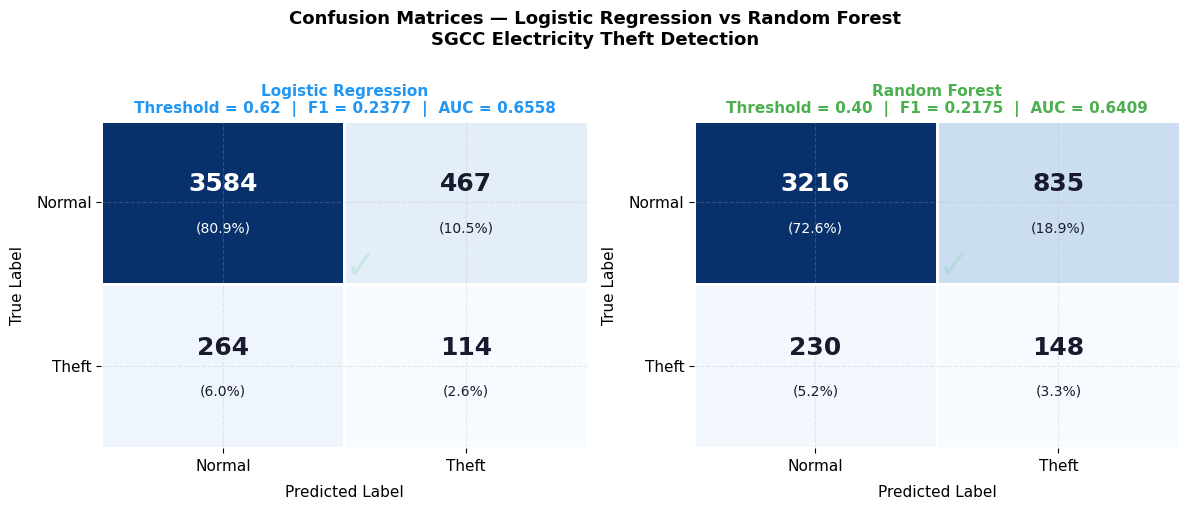

In [31]:
# ─────────────────────────────────────────────────────────────
# V1 — Side-by-side Confusion Matrix Heatmaps
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — Logistic Regression vs Random Forest\n'
             'SGCC Electricity Theft Detection', fontsize=13, fontweight='bold', y=1.01)

for ax, res, color in zip(axes,
                           [lr_results, rf_results],
                           [CLR_LR,     CLR_RF]):
    cm = np.array([[res['TN'], res['FP']],
                   [res['FN'], res['TP']]])
    total = cm.sum()

    # colour map centred on the off-diagonal (errors)
    sns.heatmap(cm, annot=False, fmt='d', ax=ax, cmap='Blues',
                linewidths=2, linecolor='white', cbar=False)

    # custom annotations — value + percentage
    tick_labels = ['Normal', 'Theft']
    for i in range(2):
        for j in range(2):
            val  = cm[i, j]
            pct  = val / total * 100
            cell_color = 'white' if cm[i, j] > cm.max() / 2 else '#1a1a2e'
            ax.text(j + 0.5, i + 0.38, f'{val}',
                    ha='center', va='center',
                    fontsize=18, fontweight='bold', color=cell_color)
            ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)',
                    ha='center', va='center',
                    fontsize=10, color=cell_color)

    # label correct / wrong cells
    ax.text(0.5, 0.5, '✓', transform=ax.transAxes,  # TN
            ha='left', va='bottom', fontsize=28,
            color='#2ecc71', alpha=0.15, fontweight='bold')

    ax.set_xticklabels(tick_labels, fontsize=11)
    ax.set_yticklabels(tick_labels, fontsize=11, rotation=0)
    ax.set_xlabel('Predicted Label', fontsize=11, labelpad=8)
    ax.set_ylabel('True Label',      fontsize=11, labelpad=8)
    ax.set_title(f"{res['Model']}\n"
                 f"Threshold = {res['Threshold']:.2f}  |  "
                 f"F1 = {res['F1-Score']:.4f}  |  AUC = {res['AUC']:.4f}",
                 fontsize=11, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('V1_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


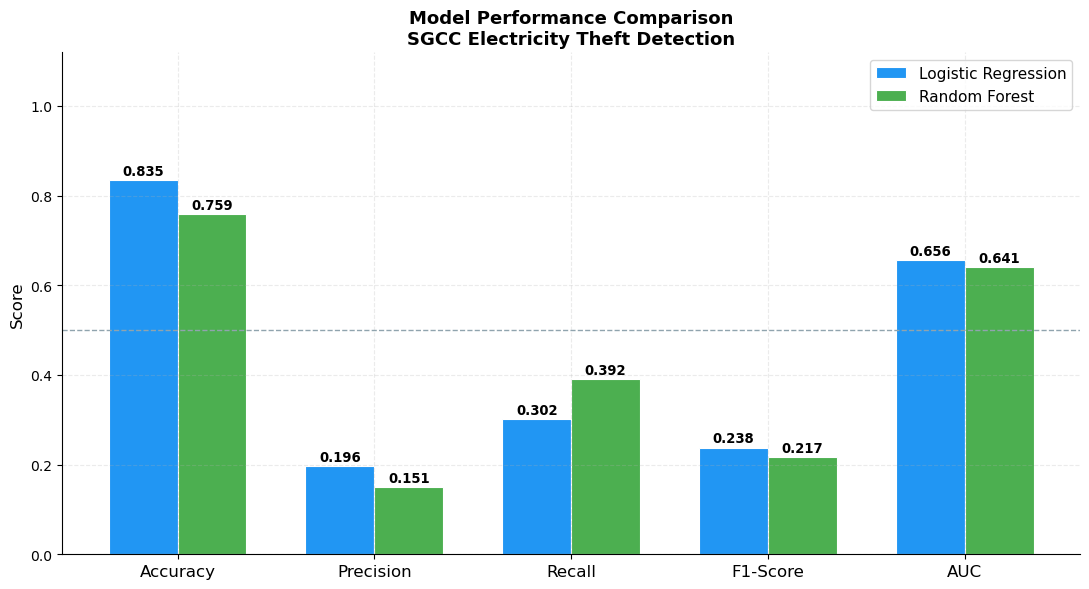

In [32]:

# ─────────────────────────────────────────────────────────────
# V2 — Grouped Metrics Bar Chart
# ─────────────────────────────────────────────────────────────
vis_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
lr_vals = [lr_results[m] for m in vis_metrics]
rf_vals = [rf_results[m] for m in vis_metrics]

x   = np.arange(len(vis_metrics))
w   = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars_lr = ax.bar(x - w/2, lr_vals, w, label='Logistic Regression',
                 color=CLR_LR, edgecolor='white', linewidth=0.8)
bars_rf = ax.bar(x + w/2, rf_vals, w, label='Random Forest',
                 color=CLR_RF, edgecolor='white', linewidth=0.8)

# value labels on top of each bar
for bars in [bars_lr, bars_rf]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9.5,
                fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(vis_metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title('Model Performance Comparison\nSGCC Electricity Theft Detection',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.axhline(0.5, color=CLR_GREY, linewidth=1, linestyle='--', label='0.5 baseline')
plt.tight_layout()
plt.savefig('V2_metrics_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

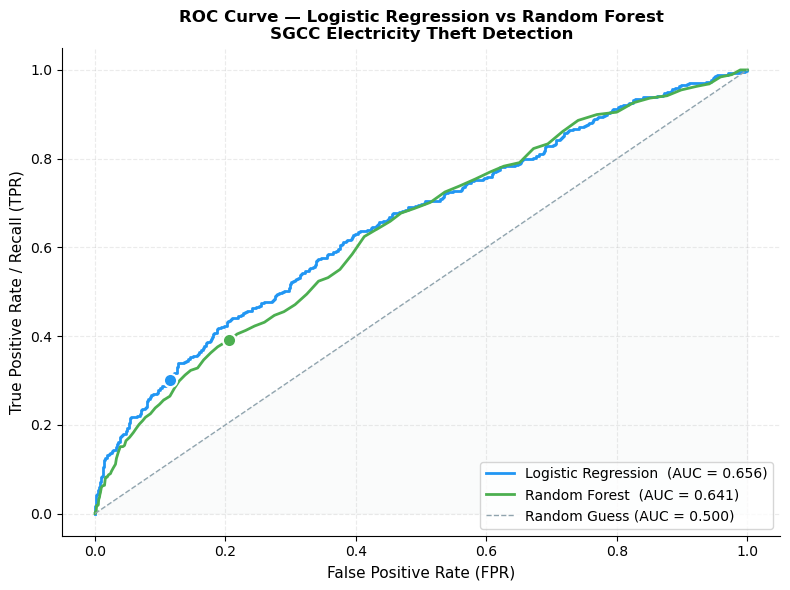

In [33]:
# ─────────────────────────────────────────────────────────────
# V3 — ROC Curve
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for res, color in [(lr_results, CLR_LR), (rf_results, CLR_RF)]:
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{res['Model']}  (AUC = {res['AUC']:.3f})")
    # mark operating point
    op_fpr = res['FP'] / (res['FP'] + res['TN'])
    op_tpr = res['Recall']
    ax.scatter([op_fpr], [op_tpr], color=color, s=90, zorder=5,
               edgecolors='white', linewidth=1.5)

ax.plot([0, 1], [0, 1], color=CLR_GREY, linewidth=1,
        linestyle='--', label='Random Guess (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color=CLR_GREY)

ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate / Recall (TPR)', fontsize=11)
ax.set_title('ROC Curve — Logistic Regression vs Random Forest\n'
             'SGCC Electricity Theft Detection', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('V7_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
